In [ ]:
import pandas as pd


df_fraud = pd.read_csv('../data/raw/IEEE-CIS Fraud Detection Dataset/train_transaction.csv')

In [2]:
df_fraud.shape

(590540, 394)

In [3]:
df_fraud.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
df_fraud['isFraud'].value_counts()

isFraud
0    569877
1     20663
Name: count, dtype: int64

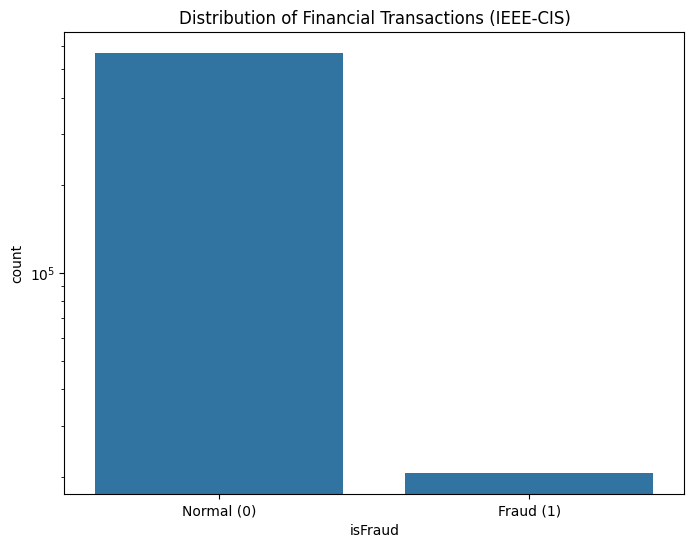

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8, 6))


sns.countplot(data=df_fraud, x='isFraud')


plt.xticks([0, 1], ['Normal (0)', 'Fraud (1)'])


plt.title('Distribution of Financial Transactions (IEEE-CIS)')
plt.yscale('log')


plt.show()

In [6]:
df_fraud.isnull().sum()

TransactionID          0
isFraud                0
TransactionDT          0
TransactionAmt         0
ProductCD              0
                   ...  
V335              508189
V336              508189
V337              508189
V338              508189
V339              508189
Length: 394, dtype: int64

In [ ]:

null_percentages = df_fraud.isnull().sum() / len(df_fraud)


df_fraud_cleaned = df_fraud.loc[:, null_percentages < 0.80]


df_fraud_cleaned.shape

(590540, 339)

In [9]:
df_fraud_cleaned.dtypes.value_counts()

float64    321
str         14
int64        4
Name: count, dtype: int64

In [ ]:

numeric_cols = df_fraud_cleaned.select_dtypes(include=['float64', 'int64']).columns


df_fraud_cleaned[numeric_cols] = df_fraud_cleaned[numeric_cols].fillna(df_fraud_cleaned[numeric_cols].median())


df_fraud_cleaned[numeric_cols].isnull().sum().max()

np.int64(0)

In [ ]:

text_cols = df_fraud_cleaned.select_dtypes(include=['object']).columns


df_fraud_cleaned[text_cols] = df_fraud_cleaned[text_cols].fillna('Unknown')


df_fraud_cleaned.isnull().sum().max()

C:\Users\Dell\AppData\Local\Temp\ipykernel_14276\3036847255.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df_fraud_cleaned.select_dtypes(include=['object']).columns


np.int64(0)

In [13]:
# Save the cleaned dataset to the processed folder
df_fraud_cleaned.to_csv('../data/processed/fraud_cleaned.csv', index=False)